# Notebook 5 — Dashboard Preview

**Purpose:** Lightweight sanity check before launching the full Streamlit server. Load the saved model and SHAP data and render the key visualizations inline to verify everything looks correct.

In [5]:
import sys
from pathlib import Path
import joblib
import shap
import matplotlib.pyplot as plt

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
from src.paths import MODELS_DIR

### Load model and SHAP data

In [6]:
model = joblib.load(MODELS_DIR / "build_failure_model.pkl")
shap_data = joblib.load(MODELS_DIR / "shap_data.joblib")
X_sample = shap_data["X_sample"]
shap_values = shap_data["shap_values"]
feature_list = shap_data["feature_list"]
class_names = shap_data["class_names"]
print("Model and SHAP data loaded. Sample size:", len(X_sample))

Model and SHAP data loaded. Sample size: 2000


### Global summary (bar) — inline

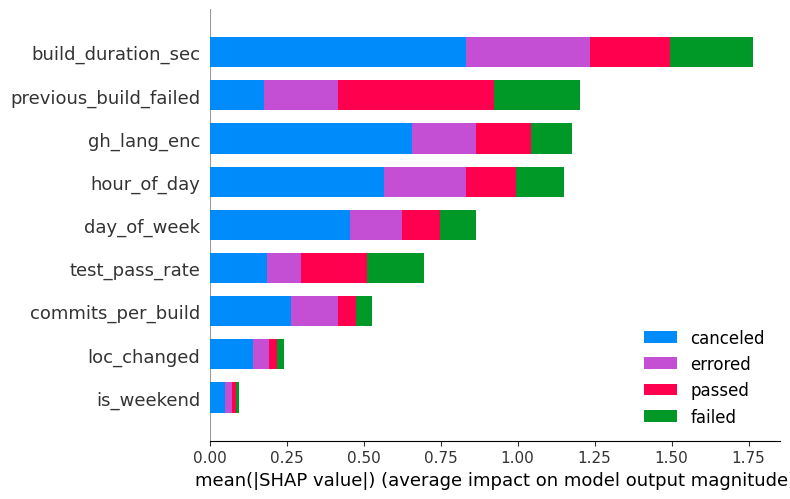

In [7]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_list, class_names=class_names, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### Waterfall for one sample — inline

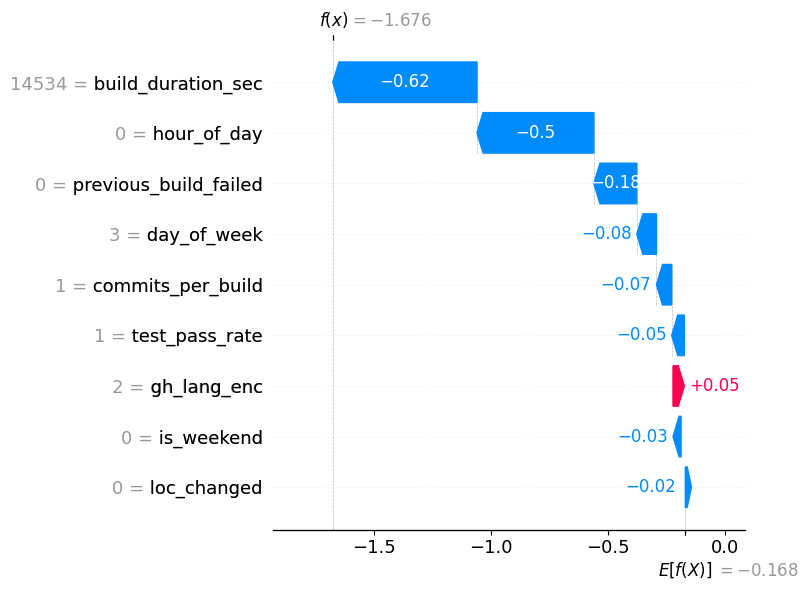

In [8]:
import numpy as np
# Explainer is recreated from model + sample (not saved in shap_data)
explainer = shap.TreeExplainer(model, X_sample)
ev = shap_data.get("expected_value", explainer.expected_value)
failed_idx = list(class_names).index("failed") if "failed" in class_names else 0
sample_idx = 0
# expected_value can be list (from joblib) or ndarray; waterfall needs a scalar float
base_val = float(ev[failed_idx]) if isinstance(ev, (list, np.ndarray)) else float(ev)
vals_1d = np.asarray(shap_values[failed_idx][sample_idx] if isinstance(shap_values, list) else shap_values[sample_idx]).flatten()
ex = shap.Explanation(values=vals_1d, base_values=base_val, data=X_sample.iloc[sample_idx].values, feature_names=feature_list)
shap.waterfall_plot(ex, show=False)
plt.tight_layout()
plt.show()